In [1]:
import json
from freezeplots import (
    combined,
    complete,
    plot_supercooling,
)


from freezeplots.paths import PROC_DATA_DIR, PLOT_DIR, CHANNEL_LAYOUT_PATH
with CHANNEL_LAYOUT_PATH.open(
    "r",
    encoding="utf-8",
) as file:
    channel_layout = json.load(file)
    
input_path = PROC_DATA_DIR / "manual_supercooling_events.csv"
output_path = PLOT_DIR / "SoilRPvsSF_WetaGrasCor-HeatMWCO.png"

Loaded 871 channel records from /home/juk/freeze/data/data_processed/manual_supercooling_events.csv
Plot saved to: /home/juk/freeze/output/plots/SoilRPvsSF_WetaGrasCor-HeatMWCO.png


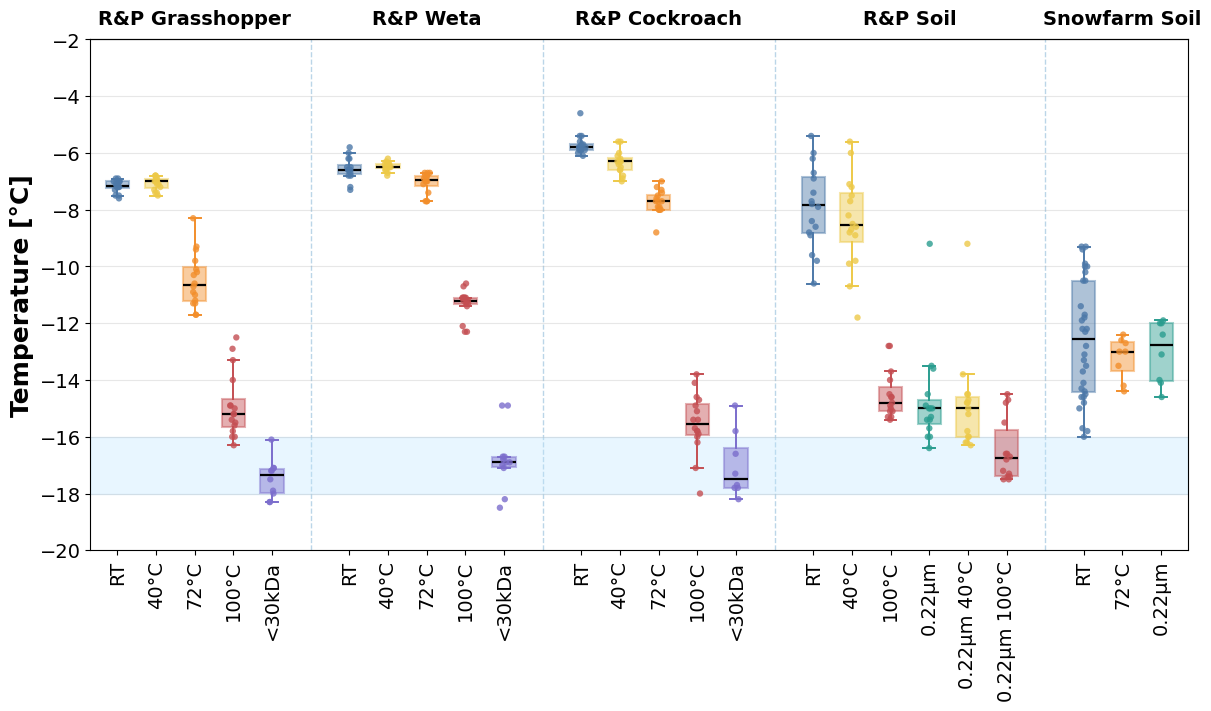

(<Figure size 1200x700 with 1 Axes>, <Axes: ylabel='Temperature [°C]'>)

In [9]:
from freezeplots import (
    combined,
    complete,
    plot_supercooling,
)

# ============================================================
# Treatment colors
# ============================================================

TREATMENT_COLORS = {
    "RT": "#4C78A8",               # medium blue

    "40°C": "#EDC948",             # golden yellow
    "72°C": "#F28E2B",             # orange
    "100°C": "#C44E52",            # dark muted red

    "0.22µm": "#2A9D8F",           # teal
    "<30kDa": "#7B6DCC",           # medium violet

    "0.22µm 40°C": "#EDC948",      # golden yellow
    "0.22µm 72°C": "#F28E2B",      # orange
    "0.22µm 100°C": "#C44E52",     # dark muted red
}


# ============================================================
# Plot structure
# ============================================================

plot_sections = [
    {
        "label": "R&P Grasshopper",
        "gap_after": 1.0,
        "plots": [
            complete("EJ19B1", "RT"),
            complete("EJ20B1", "40°C"),
            complete("EJ21B1", "72°C"),
            complete("EJ22B1", "100°C"),
            complete("EJ23B1", "<30kDa"),
        ],
    },

    {
        "label": "R&P Weta",
        "gap_after": 1.0,
        "plots": [
            complete("EJ24B1", "RT"),
            complete("EJ25B1", "40°C"),
            complete("EJ26B1", "72°C"),
            complete("EJ27B1", "100°C"),
            complete("EJ18B1", "<30kDa"),
        ],
    },

    {
        "label": "R&P Cockroach",
        "gap_after": 1.0,
        "plots": [
            complete("EJ29B1", "RT"),
            complete("EJ30B1", "40°C"),
            complete("EJ31B1", "72°C"),
            complete("EJ32B1", "100°C"),
            complete("EJ33B1", "<30kDa"),
        ],
    },

    {
        "label": "R&P Soil",
        "gap_after": 1.0,
        "plots": [
            complete("EJ09B1", "RT"),
            complete("EJ10B1", "40°C"),
            complete("EJ11B1", "100°C"),
            complete("EJ12B1", "0.22µm"),
            complete("EJ13B1", "0.22µm 40°C"),
            complete("EJ14B1", "0.22µm 100°C"),
        ],
    },

    {
        "label": "Snowfarm Soil",
        "gap_after": 1.0,
        "plots": [
            combined(
                "RT",
                {
                    "EJ01A1": [
                        "TC1", "TC2", "TC3", "TC4",
                        "TC5", "TC6", "TC7", "TC8",
                    ],
                    "EJ01A2": [
                        "TC1", "TC2", "TC3", "TC4",
                        "TC5", "TC6", "TC7", "TC8",
                    ],
                    "EJ01A3": [
                        "TC1", "TC2", "TC3", "TC4",
                        "TC5", "TC6", "TC7", "TC8",
                    ],
                    "EJ01A4": [
                        "TC1", "TC2", "TC3", "TC4",
                        "TC5", "TC6", "TC7", "TC8",
                    ],
                },
            ),

            combined(
                "72°C",
                {
                    "EJ02A1": ["TC5", "TC6", "TC7", "TC8"],
                    "EJ02A2": ["TC5", "TC6", "TC7", "TC8"],
                },
            ),

            combined(
                "0.22µm",
                {
                    "EJ02A1": ["TC9", "TC10", "TC11", "TC12"],
                    "EJ02A2": ["TC9", "TC10", "TC11", "TC12"],
                },
            ),
        ],
    },
]


# ============================================================
# Generate plot
# ============================================================

plot_supercooling(
    plot_sections=plot_sections,
    treatment_colors=TREATMENT_COLORS,
    input_path=input_path,
    output_path=output_path,
    title=None,
    show_legend=False,
    x_label_rotation=90,

    figsize=(12, 7),
    y_range=(-20, -2),
    tick_label_size=14,
    group_label_size=14,
    axis_label_size=18,

)